<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_download_ReBeatICG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code Part

## Download Dataset


In [70]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

mkdir: cannot create directory ‘/content/RawData/’: File exists
mkdir: cannot create directory ‘/content/FilteredData/’: File exists
mkdir: cannot create directory ‘/content/Annotations/’: File exists


In [148]:

import numpy as np
import pandas as pd
import scipy.io as sio

subject = input("Enter subject number: ")  # example: '24'
task = input("Enter task name: ")  # 'CW' or 'BL'

filename_raw = f'/content/RawData/RawData_Subject_{subject}_task_{task}.mat'
data_raw = sio.loadmat(filename_raw)

filename_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
data_filtered = sio.loadmat(filename_filtered)

filename_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'
annotation = sio.loadmat(filename_annotation)



Enter subject number: 22
Enter task name: CW


## Variable extraction
#### fs = 250 and 74469 samples -> 297.876 seconds = 4.9646 min




In [149]:
print(data_raw.keys())
print(data_filtered.keys())
print(annotation.keys())

# raw data variables
ecg_raw = data_raw['ECG']
icg_raw = data_raw['ICG']
fs_raw = data_raw['samplFreq']

# filtered data variables
ecg_filtered = data_filtered['ECG']
icg_filtered = data_filtered['ICG']
sgf = data_filtered['SGFiltLen']
fs_filtered = data_filtered['samplFreq']
print(sgf)

# annotation variables
annotations = annotation['annotPoints']
# print(fs_raw); print(fs_filtered) fs = 250
# print(len(ecg_raw)); print(len(ecg_filtered)) number of samples = 74469
print(annotations)

dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'SGFiltLen', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'annotPoints'])
[[11]]
[[30120 30138 30187 30217]
 [30333 30349 30399 30416]
 [30550 30567 30620 30636]
 [30780 30796 30851 30878]
 [31017 31035 31086 31116]
 [31251 31267 31321 31337]
 [31489 31506 31557 31586]
 [31729 31746 31801 31831]
 [31962 31977 32035 32049]
 [32202 32220 32274 32302]
 [20838 20851 20904 20923]
 [21065 21081 21132 21159]
 [21282 21299 21352 21381]
 [21494 21508 21561 21591]
 [21708 21726 21778 21807]
 [21923 21943 21990 22022]
 [22145 22160 22225 22246]
 [22374 22392 22457 22476]
 [22619 22638 22693 22722]
 [22879 22899 22964 22982]
 [35265 35282 35340 35370]
 [35525 35543 35600 35630]
 [35787 35803 35861 35892]
 [36047 36065 36132 36150]
 [36301 36320 36375 36408]
 [36560 36575 36634 36648]
 [36816 36834 36891 36919]
 [37072 37090 

## Raw data plots

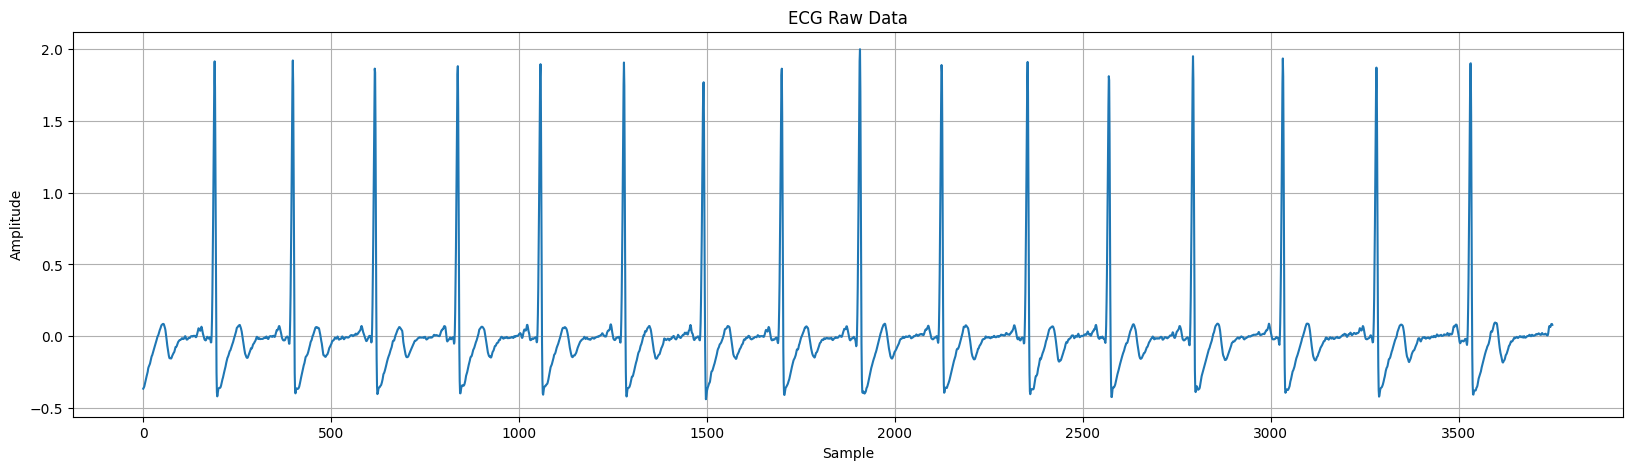

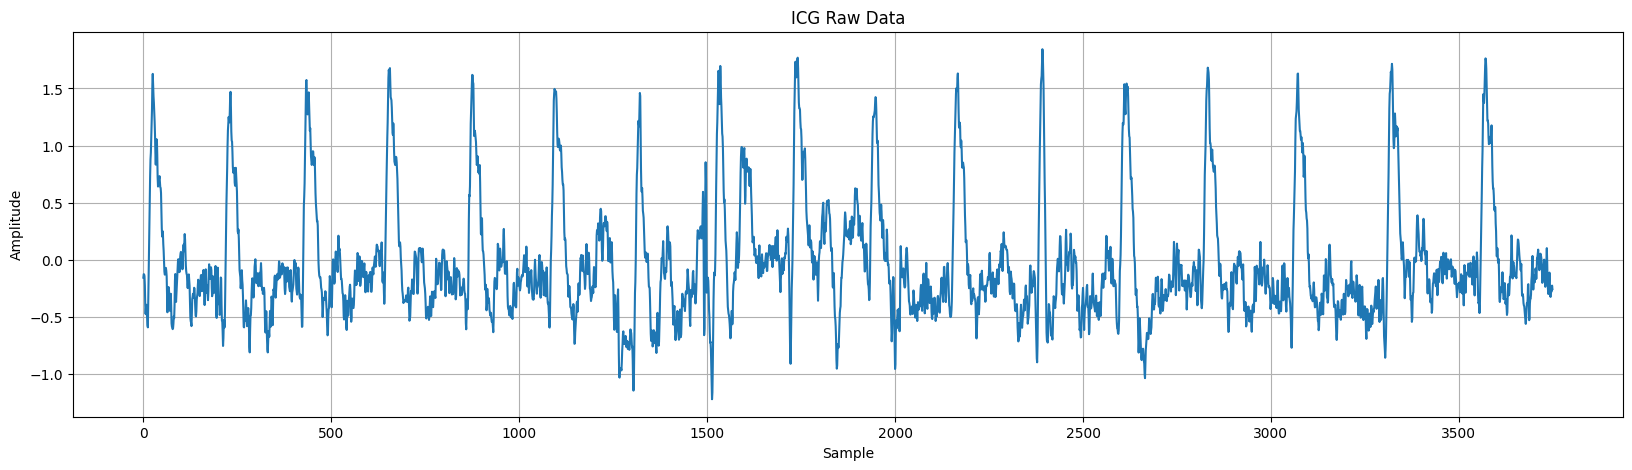

In [150]:
import matplotlib.pyplot as plt

# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_raw[0:3750])
plt.title('ECG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_raw[0:3750])
plt.title('ICG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Filtered data plots

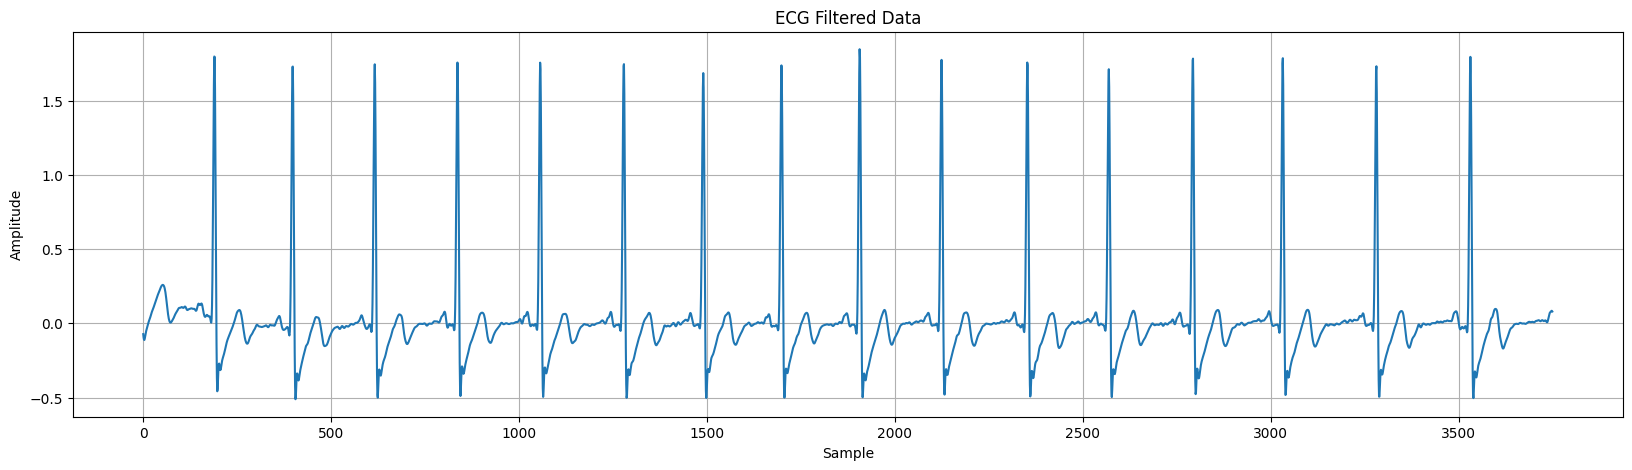

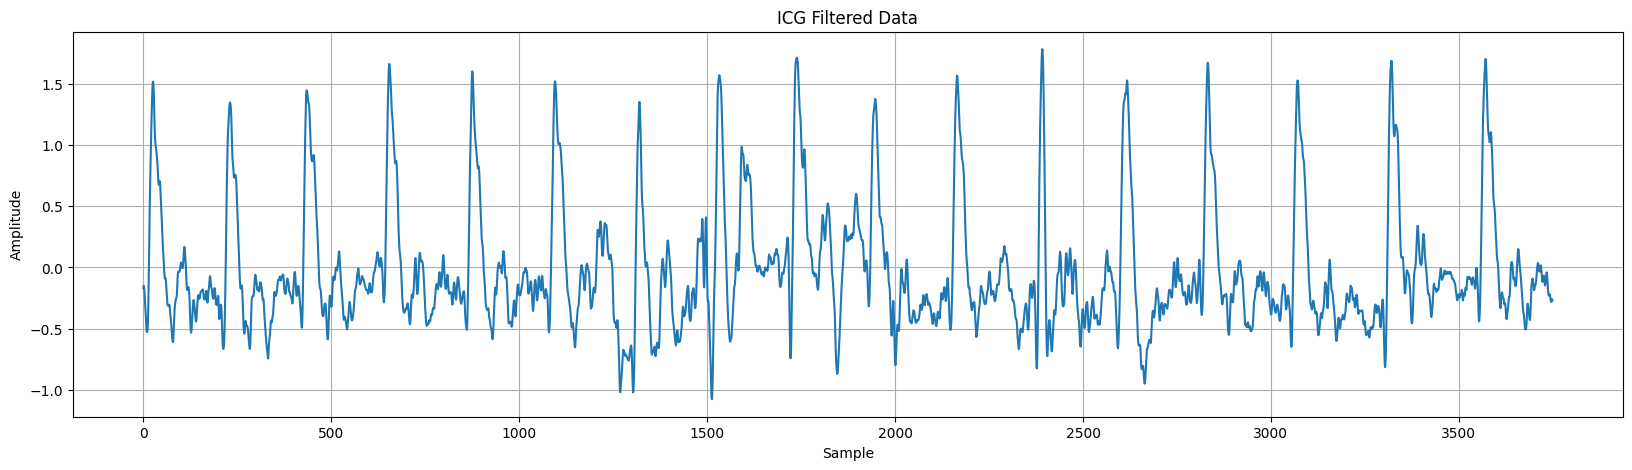

In [151]:
# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered[0:3750])
plt.title('ECG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_filtered[0:3750])
plt.title('ICG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Annotations plot


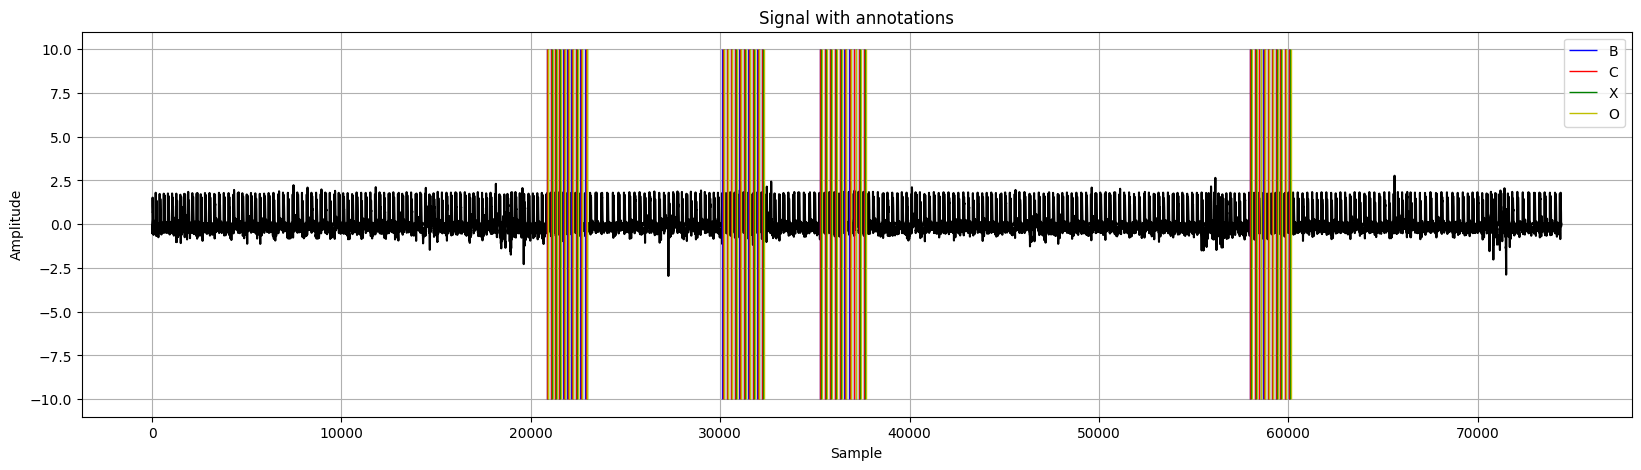

In [152]:
samples = np.arange(0, 74470, 1)

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered,'k')
plt.plot(icg_filtered,'k') # Overlay ICG signal
plt.vlines(B, ymin=-10, ymax=10, color='b', linewidth=1, label='B')
plt.vlines(C, ymin=-10, ymax=10, color='r', linewidth=1, label='C')
plt.vlines(X, ymin=-10, ymax=10, color='g', linewidth=1, label='X')
plt.vlines(O, ymin=-10, ymax=10, color='y', linewidth=1, label='O')

plt.title('Signal with annotations')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend() # Add legend
plt.grid(True)
plt.show()


### Events plot

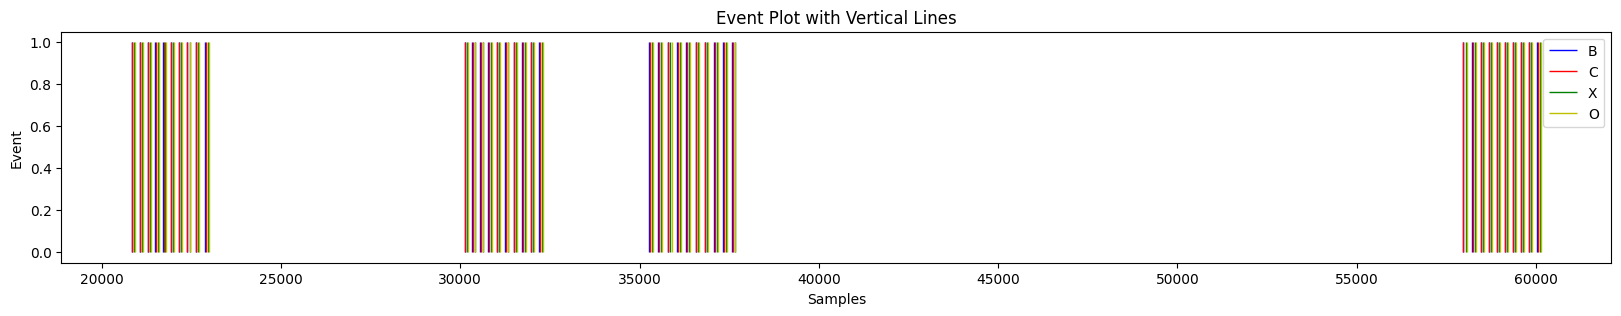

In [153]:

plt.figure(figsize=(20, 3))

plt.vlines(B, ymin=0, ymax=1, color='b', linewidth=1, label='B')
plt.vlines(C, ymin=0, ymax=1, color='r', linewidth=1, label='C')
plt.vlines(X, ymin=0, ymax=1, color='g', linewidth=1, label='X')
plt.vlines(O, ymin=0, ymax=1, color='y', linewidth=1, label='O')

plt.xlabel('Samples')
plt.ylabel('Event')
plt.title('Event Plot with Vertical Lines')
plt.legend()
plt.show()

### Event plot with slide


In [154]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

samples = np.arange(0, 74470, 1)  # From 0 to 74469 with step 1

# Update function
def update_plot(start_sample, end_sample):
    plt.figure(figsize=(20, 3))
    plt.plot(ecg_filtered,'b',linewidth = 1)
    plt.plot(icg_filtered,'k',linewidth = 1) # Overlay ICG signal
    # Compute the min and max amplitudes for the selected range of samples
    min_amplitude = min(np.min(ecg_filtered[start_sample:end_sample]), np.min(icg_filtered[start_sample:end_sample]))
    max_amplitude = max(np.max(ecg_filtered[start_sample:end_sample]), np.max(icg_filtered[start_sample:end_sample]))

    # Plot event markers with dynamic ymin and ymax based on the min and max amplitudes
    plt.vlines(B[(B >= start_sample) & (B <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='r', linewidth=1, label='B')  # Vertical line for event B
    plt.vlines(C[(C >= start_sample) & (C <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='y', linewidth=1, label='C')  # Vertical line for event C
    plt.vlines(X[(X >= start_sample) & (X <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='g', linewidth=1, label='X')  # Vertical line for event X
    plt.vlines(O[(O >= start_sample) & (O <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='m', linewidth=1, label='O')  # Vertical line for event O

    plt.xlabel('Samples')
    plt.ylabel('Event')
    plt.ylim([-3,3])
    plt.title('Event Plot with Vertical Lines')
    plt.legend()
    plt.xlim(start_sample, end_sample)  # Limit the sample range
    plt.show()

# Create interactive sliders
start_slider = widgets.IntSlider(min=0, max=len(samples) - 100, step=10, value=0, description="Start:")
end_slider = widgets.IntSlider(min=100, max=len(samples), step=10, value=len(samples), description="End:")

# Link sliders to the update function
interactive_plot = widgets.interactive(update_plot, start_sample=start_slider, end_sample=end_slider)

# Display the sliders and the interactive plot
display(interactive_plot, start_slider, end_slider)

interactive(children=(IntSlider(value=0, description='Start:', max=74370, step=10), IntSlider(value=74470, des…

IntSlider(value=0, description='Start:', max=74370, step=10)

IntSlider(value=74470, description='End:', max=74470, min=100, step=10)